Analisis de datos sobre base de datos de accidentes aereos desde 1971 a 2024

In [113]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

Importacion de el dataset desde el repo publico

In [63]:
crashes_full = pd.read_csv("https://raw.githubusercontent.com/rmbriend/AndD-public/refs/heads/master/datasets/aircrahesFullDataUpdated_2024.csv")
#df_csv = pd.read_csv("https://people.sc.fsu.edu/~jburkardt/data/csv/airtravel.csv")


Limita a accidendentes ocurridos desde 1971 en adelante

In [69]:
crashes = crashes_full[crashes_full['Year'] > 1970]
crashes.head()

,Year,Quarter,Month,Day,Country/Region,Aircraft Manufacturer,Aircraft,Location,Operator,Ground,Fatalities (air),Aboard
2,1973,Qtr 2,April,10,NaN,Vickers Vanguard,Vickers Vanguard 952G AXOP,Near Basel,(UK) Airlines International SwitzerlandInvicta,0,108,145
3,2000,Qtr 2,April,19,'-,Antonov,Antonov AN 8TL,Pepa -,Airlines Centrafricain,0,24,24
6,2024,Qtr 2,April,23,Alaska,Douglas,Douglas C-54D Skymaster N3054V,Near Fairbanks,Alaska Air Fuel,0,2,2
8,1997,Qtr 2,April,23,Afghanistan,Antonov,Antonov AN 26?,Near Konduz Afghanistan,Force Air Republican Afghan - Military,0,36,36
9,1988,Qtr 2,April,10,Afghanistan,Antonov,Antonov AN 26?,Near Mazâr-e Charif Afghanistan,Force Air Republican Afghan - Military,0,29,29


In [70]:
crashes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2500 entries, 2 to 5033
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Year                   2500 non-null   int64 
 1   Quarter                2500 non-null   object
 2   Month                  2500 non-null   object
 3   Day                    2500 non-null   int64 
 4   Country/Region         2418 non-null   object
 5   Aircraft Manufacturer  2500 non-null   object
 6   Aircraft               2500 non-null   object
 7   Location               2500 non-null   object
 8   Operator               2416 non-null   object
 9   Ground                 2500 non-null   int64 
 10  Fatalities (air)       2500 non-null   int64 
 11  Aboard                 2500 non-null   int64 
dtypes: int64(5), object(7)
memory usage: 253.9+ KB


In [ ]:
Transforma variables categoricas en categorias

In [98]:
categoricas = ['Country/Region','Aircraft Manufacturer','Aircraft','Location','Operator']
dtype_map={col: 'category' for col in categoricas} 
crashes = crashes.astype(dtype_map) # Aplicamos el mapping al DataFrame

crashes.dtypes

Year                        int64
Quarter                    object
Month                      object
Day                         int64
Country/Region           category
Aircraft Manufacturer    category
Aircraft                 category
Location                 category
Operator                 category
Ground                      int64
Fatalities (air)            int64
Aboard                      int64
dtype: object

Las variables "Fatalities (air)", "Aboard" y "Ground" indican victimas fatales, pasajeros a bordo y victimas en tierra de cada accidente, respectivamente

In [91]:
print('Moda de victimas fatales: ', int(st.mode(crashes['Fatalities (air)'])[0]))
print('Media de victimas fatales: ', int(np.mean(crashes['Fatalities (air)'])))
print('Mediana de victimas fatales: ', int(np.median(crashes['Fatalities (air)'])))

Moda de victimas fatales:  2
Media de victimas fatales:  27
Mediana de victimas fatales:  11


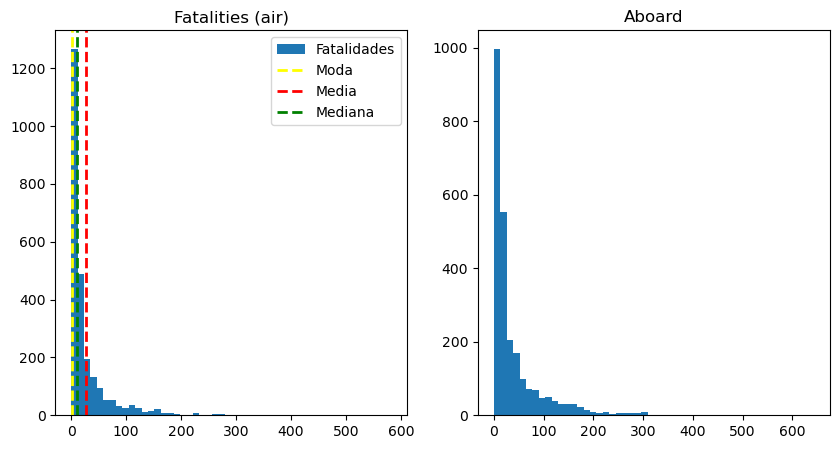

In [78]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].hist(crashes['Fatalities (air)'],bins=50,label='Fatalidades')   # fatalidades
ax[0].axvline(crashes['Fatalities (air)'].mode()[0], color='yellow', ls='--', lw=2, label='Moda')
ax[0].axvline(crashes['Fatalities (air)'].mean(), color='red', ls='--', lw=2, label='Media')
ax[0].axvline(crashes['Fatalities (air)'].median(), color='green', ls='--', lw=2, label='Mediana')
ax[0].set_title('Fatalities (air)')
ax[0].legend()
ax[1].hist(crashes['Aboard'],bins=50)  # posajeros
ax[1].set_title('Aboard')

plt.show()

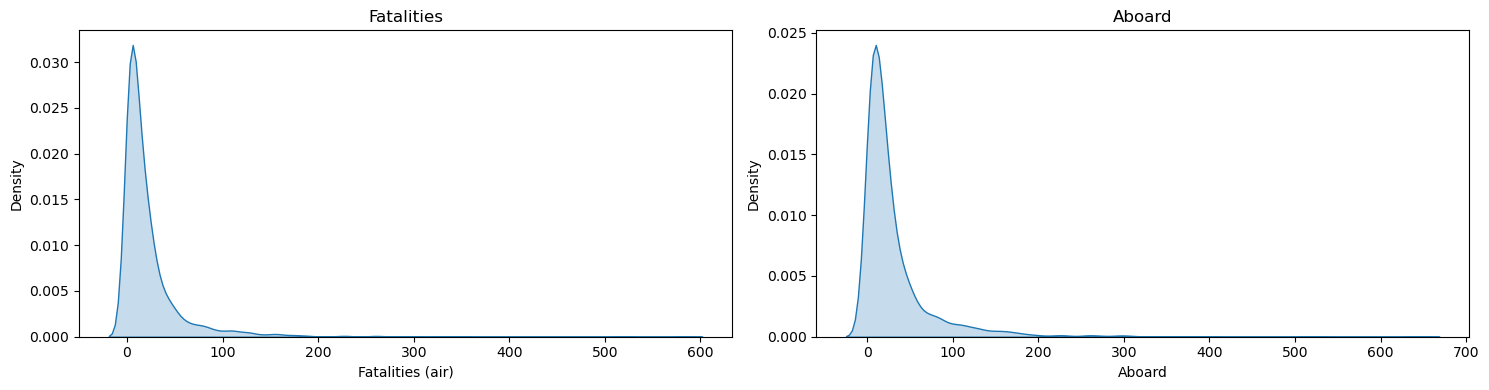

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.kdeplot(data=crashes, x='Fatalities (air)', fill=True, ax=axes[0])
sns.kdeplot(data=crashes, x='Aboard', fill=True, ax=axes[1])
axes[0].set_title('Fatalities')
axes[1].set_title('Aboard')

plt.tight_layout()
plt.show()

In [94]:
print(f"Asímetría de la variable 'Fatalities (air)': {crashes['Fatalities (air)'].skew():.4f}", '. Altamente asimetrica')
print(f"Curtosis de la variable 'Fatalities (air)': {crashes['Fatalities (air)'].kurtosis():.4f}", '. Leptocuritica')

Asímetría de la variable 'Fatalities (air)': 3.9047 . Altamente asimetrica
Curtosis de la variable 'Fatalities (air)': 24.3393 . Leptocuritica


In [ ]:
Sumariza fatalidades por año

In [118]:
resumen_anual = crashes.groupby(['Year']).sum('Fatalities (air)')
resumen_anual.head()

,Day,Ground,Fatalities (air),Aboard
Year,,,,
1971,1049,0,1784,2422
1972,1243,54,2796,3471
1973,1131,16,2323,3325
1974,870,0,2242,2878
1975,861,9,1460,2167


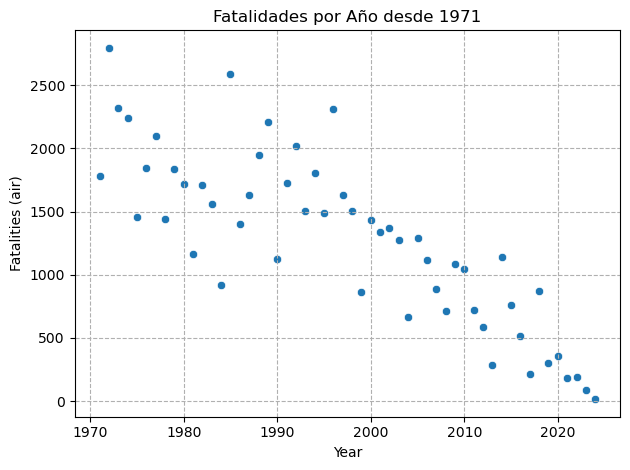

In [112]:
sns.scatterplot(data=resumen_anual, x='Year', y='Fatalities (air)', alpha=1)
plt.grid(ls='--')
plt.title('Fatalidades por Año desde 1971')
plt.tight_layout()
plt.show()

In [ ]:
Visualmente se puede verificar una relacion entre el paso del tiempo y la caida de las victimas fatales

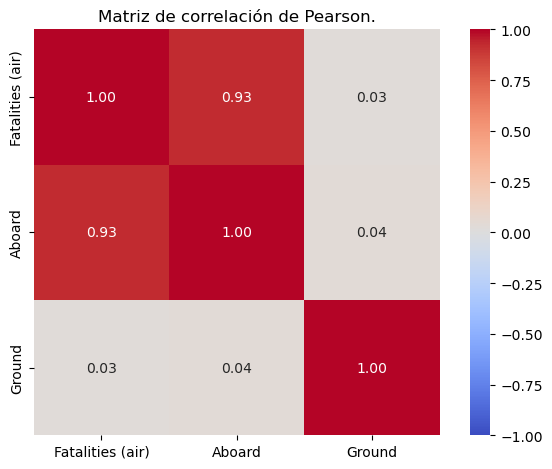

In [122]:
# Opción 1: mostrar toda la matriz de correlación como sale
crashes_numericas = ['Fatalities (air)', 'Aboard','Ground']
corr_matrix = resumen_anual[crashes_numericas].corr()

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True)
plt.title('Matriz de correlación de Pearson.')
plt.tight_layout()
plt.show()

Existe fuerte correlacion entre las fatalidades y la cantidad de pasajeros a bordo (logico), no asi entre estas dos y las fatalidades en tierra

In [124]:
crashes.describe(include='category')

,Country/Region,Aircraft Manufacturer,Aircraft,Location,Operator
count,2418,2500,2500,2500,2416
unique,365,323,1800,2194,1696
top,Russia,Boeing,Boeing B 737,Manila Philippines,Aeroflot
freq,158,281,73,11,87
